# Adaptive Tree Hat Basis — Demonstration

This notebook demonstrates the **adaptive tree hat basis** on $[0,1]^D$
implemented in [`adaptive_grid_tree.py`](adaptive_grid_tree.py). It shows how
*refining the tree improves the resolution* of the function representation in
both 1D and 2D.

**No statistical inference is done here.** To isolate the approximation power of
the basis we simply project a *known* target function onto the current basis by
ordinary least squares — this is the best the basis can do at a given
refinement, independent of any sampler. Bayesian inference over the tree comes
later.

### Recap of the basis (see `sec:hat-tree` in the draft)

In each dimension independently, the 1D components follow a fixed child rule:

| level | function | children |
|---|---|---|
| 0 | $f(x)=1$ (const) | const $\to$ linear |
| 1 | $f(x)=x$ (linear) | linear $\to$ unit hat |
| 2 | $\hat(x;0,1)$ (unit hat) | split at midpoint |
| $\ge 3$ | $\hat(x;lo,hi)$ | left $\hat(x;lo,m)$, right $\hat(x;m,hi)$ |

A $D$-dimensional basis function is a tensor product
$\phi_k(x)=\prod_d f_{s_d^{(k)}}(x_d)$. The **active basis is all nodes** — root,
internals, and leaves — which is what makes the span include smooth functions
(not just hats that vanish on every cell boundary).

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")   # this demo is CPU-only

import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import adaptive_grid_tree as agt
from adaptive_grid_tree import AdaptiveGridTree

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=3, suppress=True)

## 1. The 1D hierarchy

The first few 1D basis functions: the constant and linear ancestors, then the
unit hat, then its dyadic descendants. These are the building blocks tensored
together to form the $D$-dimensional basis.

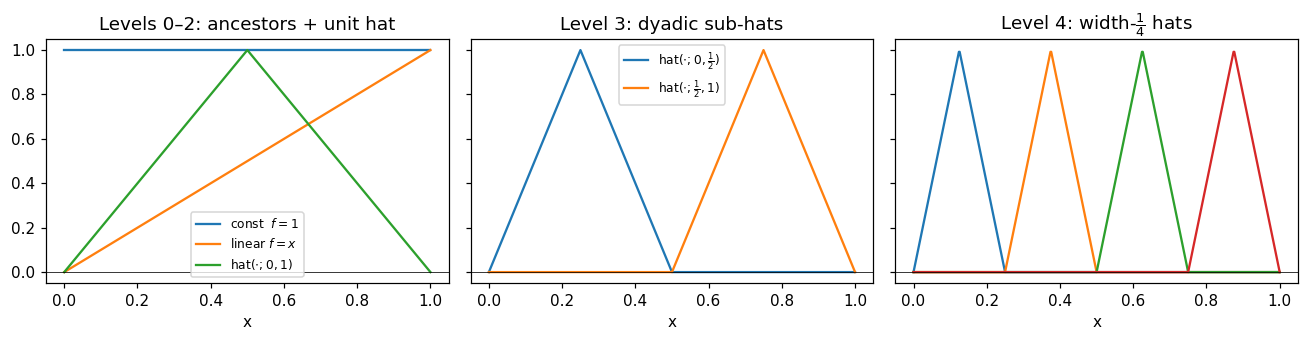

In [2]:
xx = np.linspace(0, 1, 501)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)

# level 0-2: const, linear, unit hat
axes[0].plot(xx, np.ones_like(xx),        label="const  $f=1$")
axes[0].plot(xx, xx,                       label="linear $f=x$")
axes[0].plot(xx, agt.hat1d_np(xx, 0, 1),  label=r"hat$(\cdot;0,1)$")
axes[0].set_title("Levels 0–2: ancestors + unit hat")
axes[0].legend(fontsize=8)

# level 3: the two children of the unit hat
axes[1].plot(xx, agt.hat1d_np(xx, 0.0, 0.5), label=r"hat$(\cdot;0,\frac{1}{2})$")
axes[1].plot(xx, agt.hat1d_np(xx, 0.5, 1.0), label=r"hat$(\cdot;\frac{1}{2},1)$")
axes[1].set_title("Level 3: dyadic sub-hats")
axes[1].legend(fontsize=8)

# level 4: the four grandchildren
for lo in (0.0, 0.25, 0.5, 0.75):
    axes[2].plot(xx, agt.hat1d_np(xx, lo, lo + 0.25))
axes[2].set_title(r"Level 4: width-$\frac{1}{4}$ hats")

for ax in axes:
    ax.set_xlabel("x"); ax.axhline(0, color="k", lw=0.5)
fig.tight_layout()
plt.show()

## 2. Approximation helpers

Given a tree, we build its design matrix $\Phi_{ij}=\phi_j(x_i)$ over sample
points and solve $\min_c \lVert \Phi c - y\rVert_2$ for the coefficients — i.e.
the $L^2$ projection of the target onto the current basis.

In [ ]:
def fit_coeffs(tree, X, y):
    # Least-squares (L2-projection) coefficients for target y sampled at X.
    Phi = tree.design_matrix(np.atleast_2d(X.reshape(len(X), -1)))
    coeffs, *_ = np.linalg.lstsq(Phi, y, rcond=None)
    return coeffs

def reconstruct(tree, coeffs, Xq):
    return tree.design_matrix(np.atleast_2d(Xq.reshape(len(Xq), -1))) @ coeffs

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

## 3. 1D example — uniform vs. adaptive refinement

Target: a smooth background plus a **localised sharp bump** at $x=0.3$. A good
basis should spend its degrees of freedom near the bump, not waste them on the
flat regions.

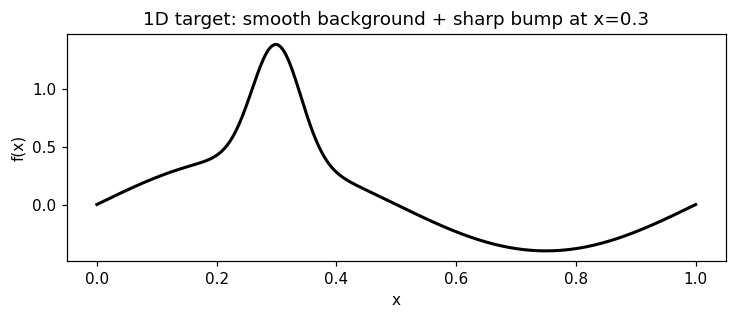

In [4]:
def target_1d(x):
    x = np.asarray(x)
    return np.exp(-0.5 * ((x - 0.30) / 0.04) ** 2) + 0.4 * np.sin(2 * np.pi * x)

X1 = np.linspace(0, 1, 400)          # sample / fit points
y1 = target_1d(X1)

plt.figure(figsize=(7, 3))
plt.plot(X1, y1, "k", lw=2)
plt.title("1D target: smooth background + sharp bump at x=0.3")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.tight_layout(); plt.show()

### Uniform refinement

Repeatedly refine **every** leaf one step. This grows the basis quickly but
spends resolution everywhere equally.

In [5]:
def uniform_step(tree):
    # Advance every current leaf one step in dim 0.
    for node in list(tree.splittable_leaves()):
        tree.refine(node, 0)

tree_u = AdaptiveGridTree(D=1, max_depth=14)
uniform_hist = []
recons_u = {}
for r in range(11):
    coeffs = fit_coeffs(tree_u, X1, y1)
    err = rmse(reconstruct(tree_u, coeffs, X1), y1)
    uniform_hist.append((tree_u.n_nodes(), err))
    if tree_u.n_nodes() in (3, 15, 63):
        recons_u[tree_u.n_nodes()] = reconstruct(tree_u, coeffs, X1)
    uniform_step(tree_u)

print("uniform (n_basis, rmse):")
for n, e in uniform_hist:
    print(f"  {n:4d}   {e:.4e}")

uniform (n_basis, rmse):
     1   4.6287e-01
     2   3.6192e-01
     3   3.6023e-01
     5   1.6981e-01
     9   1.4271e-01
    17   3.0549e-02
    33   6.2596e-03
    65   1.3414e-03
   129   2.9594e-04
   257   5.6427e-05
   513   9.3699e-15


### Adaptive refinement

Greedy strategy: at each step, try refining every splittable leaf, keep the
single refinement that most reduces the fit error. This concentrates basis
functions where the target has structure.

In [6]:
def greedy_refine(tree, X, y, n_steps, dims=None):
    # Greedy adaptive refinement. Returns history of (n_basis, rmse) and
    # snapshots {n_basis: coeffs}.
    # The tree is mutated in place, so snapshots store the *reconstruction on
    # the fit grid X* at each step (not coeffs, which only match the tree at
    # that instant).
    dims = dims if dims is not None else list(range(tree.D))
    hist, snaps = [], {}
    c0 = fit_coeffs(tree, X, y)
    hist.append((tree.n_nodes(), rmse(reconstruct(tree, c0, X), y)))
    snaps[tree.n_nodes()] = reconstruct(tree, c0, X)
    for _ in range(n_steps):
        best = None  # (err, node, dim)
        for node in tree.splittable_leaves():
            for d in dims:
                tree.refine(node, d)
                c = fit_coeffs(tree, X, y)
                e = rmse(reconstruct(tree, c, X), y)
                if best is None or e < best[0]:
                    best = (e, node, d)
                tree.coarsen(node)
        e, node, d = best
        tree.refine(node, d)
        c = fit_coeffs(tree, X, y)
        hist.append((tree.n_nodes(), rmse(reconstruct(tree, c, X), y)))
        snaps[tree.n_nodes()] = reconstruct(tree, c, X)
    return hist, snaps

tree_a = AdaptiveGridTree(D=1, max_depth=14)
adapt_hist, adapt_snaps = greedy_refine(tree_a, X1, y1, n_steps=60)

print("adaptive final: n_basis = %d, rmse = %.4e"
      % (adapt_hist[-1][0], adapt_hist[-1][1]))

adaptive final: n_basis = 119, rmse = 8.1593e-05


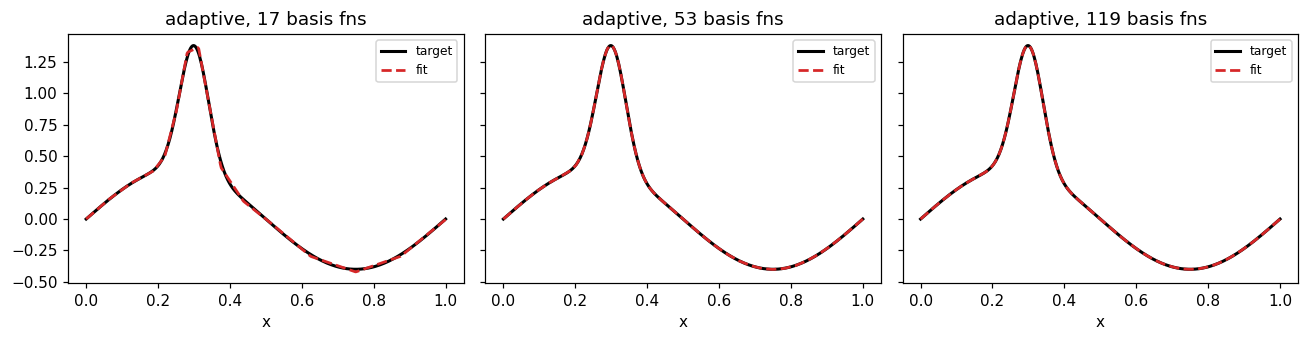

In [7]:
# Reconstructions at increasing adaptive refinement (snaps store the fit on X1)
keys = sorted(adapt_snaps)
targets = [keys[int(f * (len(keys) - 1))] for f in (0.15, 0.45, 1.0)]
fig, axes = plt.subplots(1, len(targets), figsize=(4 * len(targets), 3.2),
                         sharey=True)
for ax, n in zip(np.atleast_1d(axes), targets):
    ax.plot(X1, y1, "k", lw=2, label="target")
    ax.plot(X1, adapt_snaps[n], "C3--", lw=1.8, label="fit")
    ax.set_title(f"adaptive, {n} basis fns")
    ax.set_xlabel("x"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

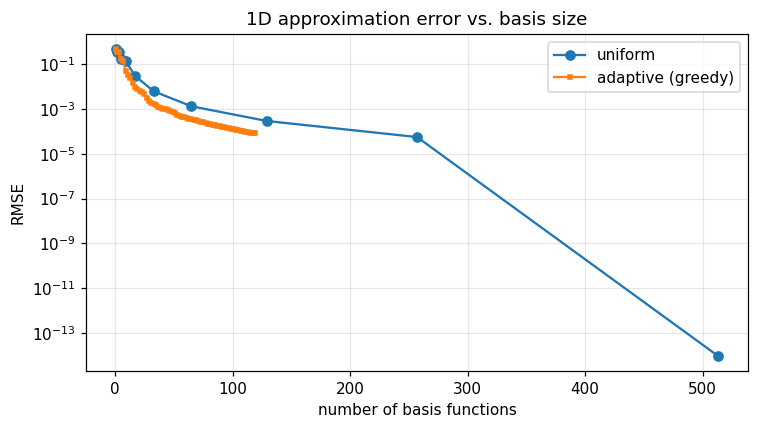

In [8]:
# Error decay: adaptive concentrates DOF where they matter
un = np.array(uniform_hist); ad = np.array(adapt_hist)
plt.figure(figsize=(7, 4))
plt.semilogy(un[:, 0], un[:, 1], "o-", label="uniform")
plt.semilogy(ad[:, 0], ad[:, 1], "s-", ms=3, label="adaptive (greedy)")
plt.xlabel("number of basis functions"); plt.ylabel("RMSE")
plt.title("1D approximation error vs. basis size")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Where did the adaptive basis put its resolution?** Plotting the support
intervals of the leaf nodes shows them clustering around the bump at $x=0.3$.

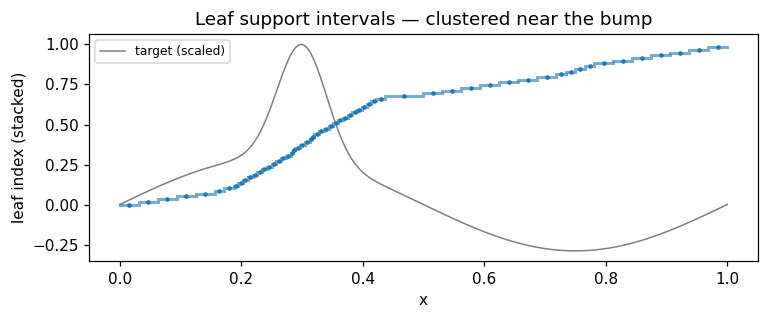

In [9]:
def leaf_boxes(tree):
    # Per-leaf support box [lo,hi] per dim (full extent for const/linear).
    boxes = []
    for node in tree.leaves():
        lo = [s.lo if s.kind == agt.HAT else 0.0 for s in node.states]
        hi = [s.hi if s.kind == agt.HAT else 1.0 for s in node.states]
        boxes.append((np.array(lo), np.array(hi)))
    return boxes

boxes = leaf_boxes(tree_a)
plt.figure(figsize=(7, 3))
plt.plot(X1, y1 / y1.max(), "k", lw=1, alpha=0.5, label="target (scaled)")
for k, (lo, hi) in enumerate(boxes):
    yk = k / len(boxes)
    plt.plot([lo[0], hi[0]], [yk, yk], "C0", lw=2, alpha=0.6)
    plt.plot((lo[0] + hi[0]) / 2, yk, "C0.", ms=4)
plt.xlabel("x"); plt.ylabel("leaf index (stacked)")
plt.title("Leaf support intervals — clustered near the bump")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. 2D example

Target: a smooth linear trend plus a localised Gaussian bump at $(0.3, 0.7)$.
We run the same greedy adaptive refinement (now choosing both *which* leaf and
*which* dimension to split) and watch the 2D reconstruction sharpen.

In [15]:
def target_2d(P):
    P = np.atleast_2d(P)
    x, y = P[:, 0], P[:, 1]
    bump = np.exp(-0.5 * (((x - 0.30) / 0.07) ** 2 + ((y - 0.70) / 0.07) ** 2))
    return bump + 0.3 * x + 0.2 * y

# fit grid
g = np.linspace(0, 1, 45)
GX, GY = np.meshgrid(g, g)
X2 = np.column_stack([GX.ravel(), GY.ravel()])
y2 = target_2d(X2)

tree2 = AdaptiveGridTree(D=2, max_depth=12)
hist2, snaps2 = greedy_refine(tree2, X2, y2, n_steps=200)
print("2D adaptive final: n_basis = %d, rmse = %.4e"
      % (hist2[-1][0], hist2[-1][1]))

2D adaptive final: n_basis = 393, rmse = 2.8570e-02


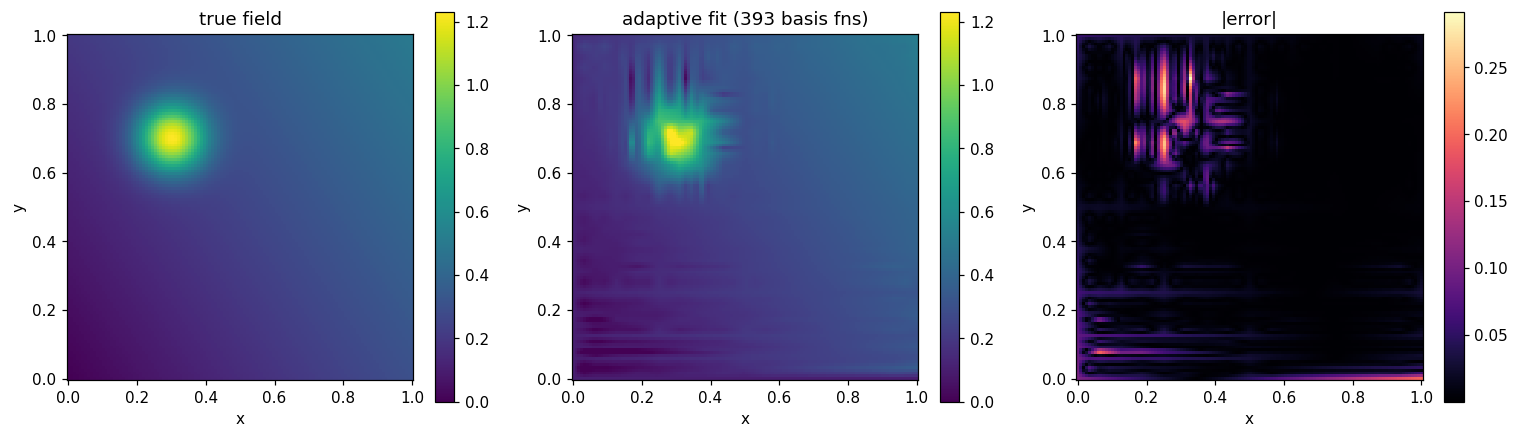

In [16]:
# dense grid for display
gd = np.linspace(0, 1, 120)
DX, DY = np.meshgrid(gd, gd)
Xd = np.column_stack([DX.ravel(), DY.ravel()])
true_field = target_2d(Xd).reshape(DX.shape)

coeffs2 = fit_coeffs(tree2, X2, y2)          # coeffs for the final tree
recon = reconstruct(tree2, coeffs2, Xd).reshape(DX.shape)
vmin, vmax = true_field.min(), true_field.max()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im0 = axes[0].pcolormesh(DX, DY, true_field, vmin=vmin, vmax=vmax, shading="auto")
axes[0].set_title("true field"); fig.colorbar(im0, ax=axes[0])
im1 = axes[1].pcolormesh(DX, DY, recon, vmin=vmin, vmax=vmax, shading="auto")
axes[1].set_title(f"adaptive fit ({hist2[-1][0]} basis fns)")
fig.colorbar(im1, ax=axes[1])
im2 = axes[2].pcolormesh(DX, DY, np.abs(recon - true_field), shading="auto",
                         cmap="magma")
axes[2].set_title("|error|"); fig.colorbar(im2, ax=axes[2])
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
fig.tight_layout(); plt.show()

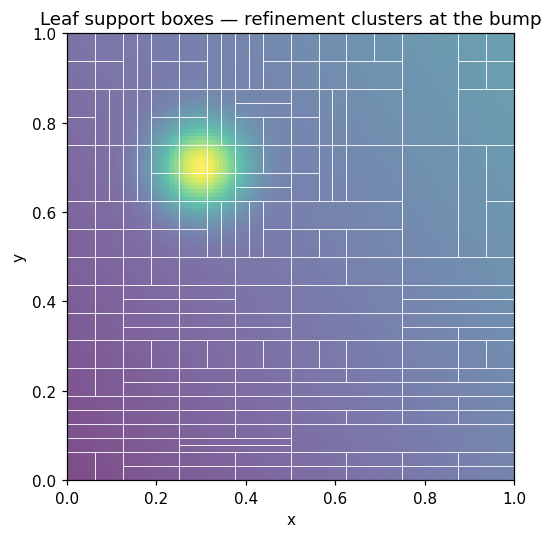

In [17]:
# Where the refinement concentrated: leaf support boxes overlaid on the field
from matplotlib.patches import Rectangle

boxes2 = leaf_boxes(tree2)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.pcolormesh(DX, DY, true_field, shading="auto", alpha=0.7)
for lo, hi in boxes2:
    ax.add_patch(Rectangle((lo[0], lo[1]), hi[0] - lo[0], hi[1] - lo[1],
                           fill=False, edgecolor="w", lw=0.6, alpha=0.7))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.set_title("Leaf support boxes — refinement clusters at the bump")
ax.set_xlabel("x"); ax.set_ylabel("y")
fig.tight_layout(); plt.show()

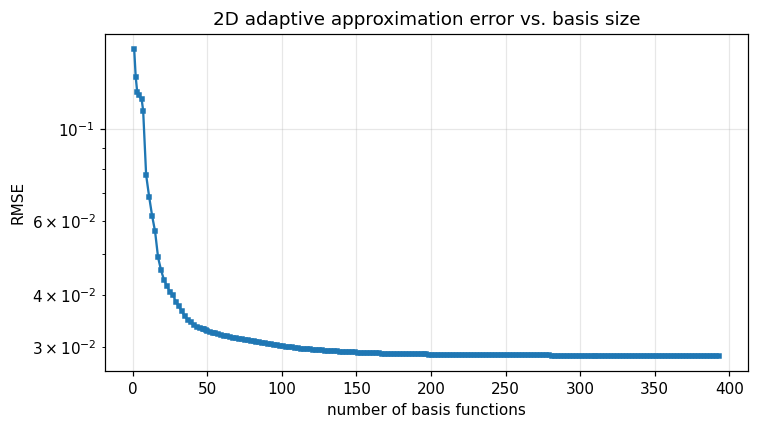

In [18]:
# 2D error decay
ad2 = np.array(hist2)
plt.figure(figsize=(7, 4))
plt.semilogy(ad2[:, 0], ad2[:, 1], "s-", ms=3)
plt.xlabel("number of basis functions"); plt.ylabel("RMSE")
plt.title("2D adaptive approximation error vs. basis size")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Cross-check: the JAX evaluation path matches the NumPy reference

The module also exposes a fixed-shape, `jit`-able evaluation path
(`compute_node_states` + `design_matrix_jax`) used downstream for inference.
Here we confirm it reproduces the NumPy `design_matrix` reconstruction exactly
on the fitted 2D tree.

In [14]:
# coeffs2 was computed above for the final tree (DFS all-nodes order)
recon_np = reconstruct(tree2, coeffs2, Xd)

ts = agt.wrap_to_tree_state(tree2, coeffs2, max_depth=12)
nk, nlo, nhi = agt.compute_node_states(ts, D=2)
Phi_jax = agt.design_matrix_jax(
    jnp.asarray(Xd), jnp.asarray(nk), jnp.asarray(nlo), jnp.asarray(nhi),
    ts.active_mask())
recon_jax = np.asarray(Phi_jax @ jnp.where(ts.active_mask(), ts.rates, 0.0))

print("max |numpy - jax| =", np.max(np.abs(recon_np - recon_jax)))
assert np.allclose(recon_np, recon_jax, atol=1e-9)
print("JAX path matches NumPy reference ✓")

max |numpy - jax| = 4.440892098500626e-16
JAX path matches NumPy reference ✓


## Summary

- The adaptive tree hat basis represents functions on $[0,1]^D$ as a tensor
  product hierarchy (const $\to$ linear $\to$ hat $\to$ dyadic sub-hats), with
  **all nodes active**.
- **Refining the tree improves resolution**, and a greedy *adaptive* refinement
  reaches a given accuracy with far fewer basis functions than uniform
  refinement by concentrating degrees of freedom where the target has structure
  (the bump).
- The same behaviour holds in 2D, where refinement also selects *which
  dimension* to split.
- The NumPy and JAX evaluation paths agree, so the basis is ready for the
  reversible-jump inference developed later.